# CANDLE/FCIS - Architecture Visualization

Create publication-quality framework diagrams and DAG visualizations matching the reference architecture.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from architecture_viz import ArchitectureVisualizer, DAGVisualizer, create_architecture_summary

# Set high DPI for publication quality
plt.rcParams['figure.dpi'] = 150

## 1. Full Framework Architecture Diagram

Creates the 7-layer architecture diagram showing:
1. Data Ingestion
2. Preprocessing
3. Temporal Causal Discovery
4. Causal Inference
5. Counterfactual Simulation
6. Alpha Generation
7. Output & Visualization

In [2]:
# Load or create sample causal graph
import pickle

try:
    with open('../data/processed/causal_graph.pkl', 'rb') as f:
        graph = pickle.load(f)
    print(f"✓ Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
except:
    try:
        graph = nx.read_graphml('../data/processed/causal_graph.graphml')
        print(f"✓ Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
    except:
        print("⚠ Creating sample graph for demonstration...")
        # Create sample graph
        graph = nx.DiGraph()
        
        # Add nodes by type
        sentiment_nodes = ['sentiment_mean', 'sentiment_vol', 'sentiment_ma5']
        stock_nodes = ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK']
        tech_nodes = ['RELIANCE_MA20', 'TCS_RSI']
        
        for n in sentiment_nodes + stock_nodes + tech_nodes:
            graph.add_node(n)
        
        # Add causal edges
        graph.add_edge('sentiment_mean', 'RELIANCE', weight=0.85, lag=1)
        graph.add_edge('sentiment_mean', 'TCS', weight=0.75, lag=1)
        graph.add_edge('sentiment_mean', 'INFY', weight=0.65, lag=2)
        graph.add_edge('sentiment_vol', 'HDFCBANK', weight=0.55, lag=1)
        graph.add_edge('RELIANCE', 'TCS', weight=0.45, lag=0)
        graph.add_edge('TCS', 'INFY', weight=0.40, lag=1)
        graph.add_edge('RELIANCE_MA20', 'RELIANCE', weight=0.70, lag=0)
        graph.add_edge('sentiment_mean', 'RELIANCE_MA20', weight=0.35, lag=3)
        
        print(f"✓ Created sample graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")

✓ Loaded graph with 25 nodes and 211 edges


### Generate Full Architecture Diagram

Architecture diagram saved to ../results/figures/candle_full_architecture.png


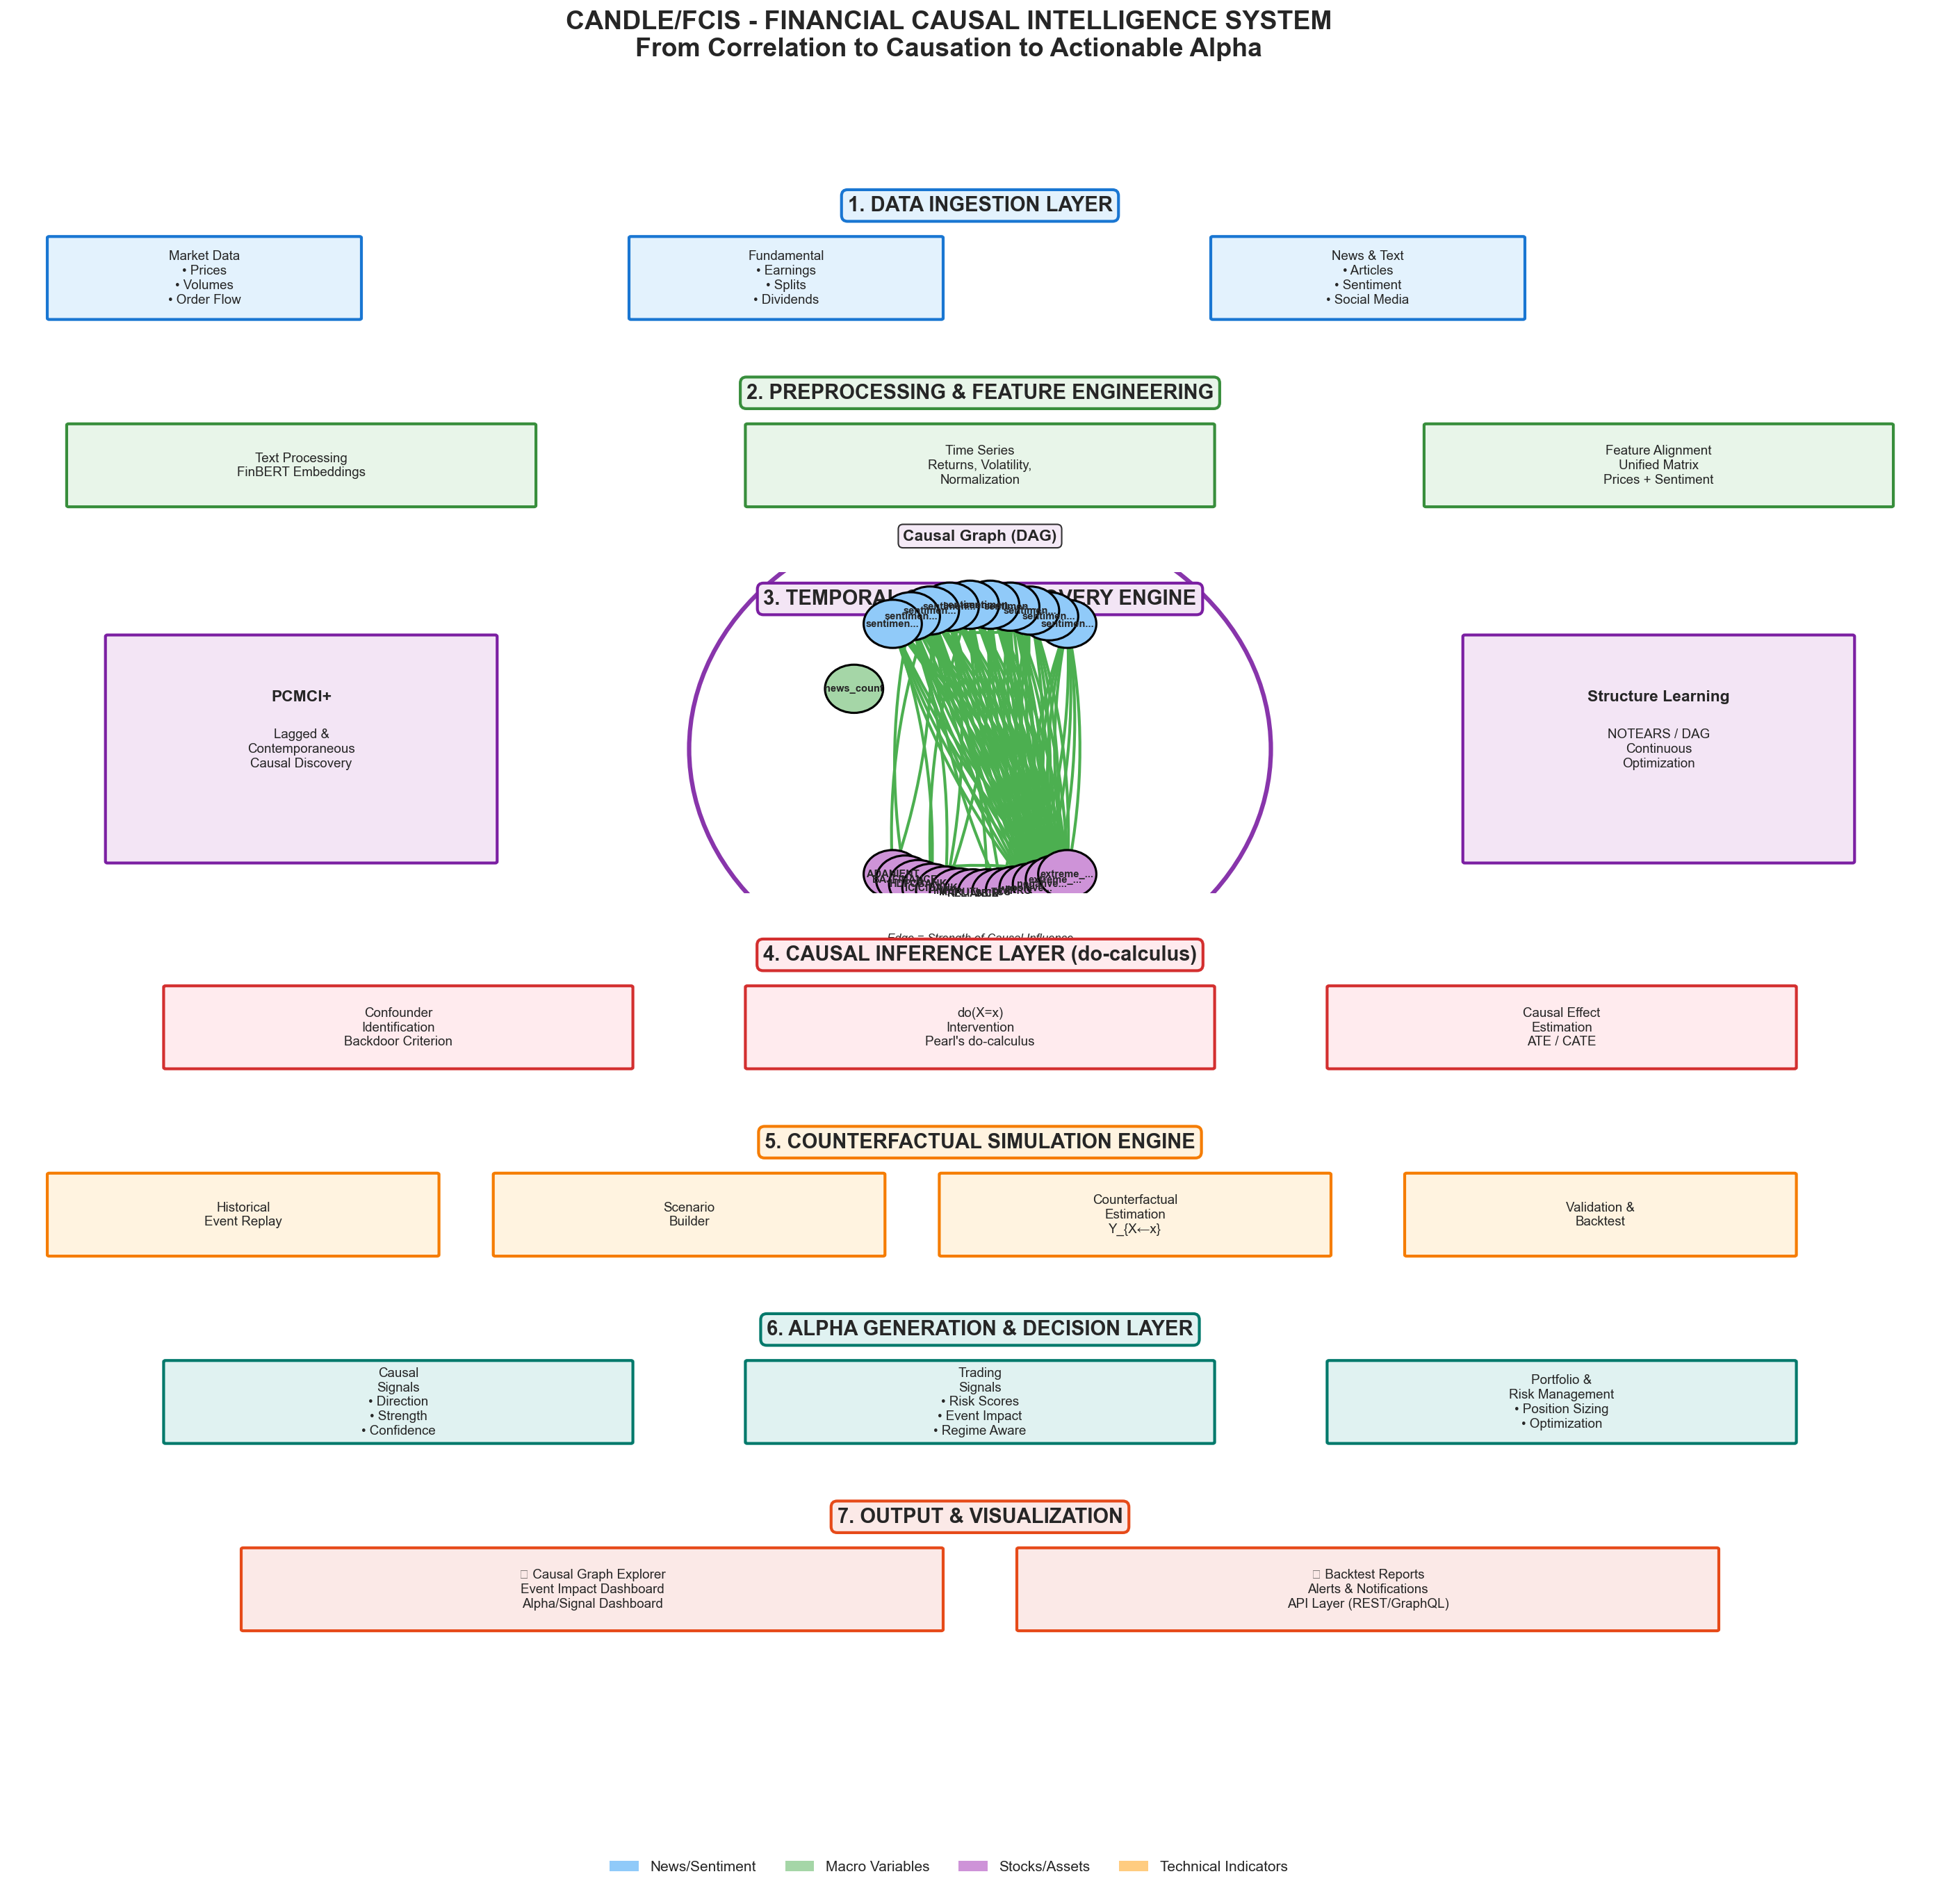


✓ Full architecture diagram saved to: results/figures/candle_full_architecture.png


In [3]:
# Create architecture visualizer
arch_viz = ArchitectureVisualizer(figsize=(24, 18))

# Generate full framework diagram
fig = arch_viz.create_framework_architecture(
    causal_graph=graph,
    save_path='../results/figures/candle_full_architecture.png'
)

plt.show()

print("\n✓ Full architecture diagram saved to: results/figures/candle_full_architecture.png")

## 2. Publication-Quality Causal DAG

Create clean DAG visualization for papers/presentations.

DAG saved to ../results/figures/causal_graph_publication.png


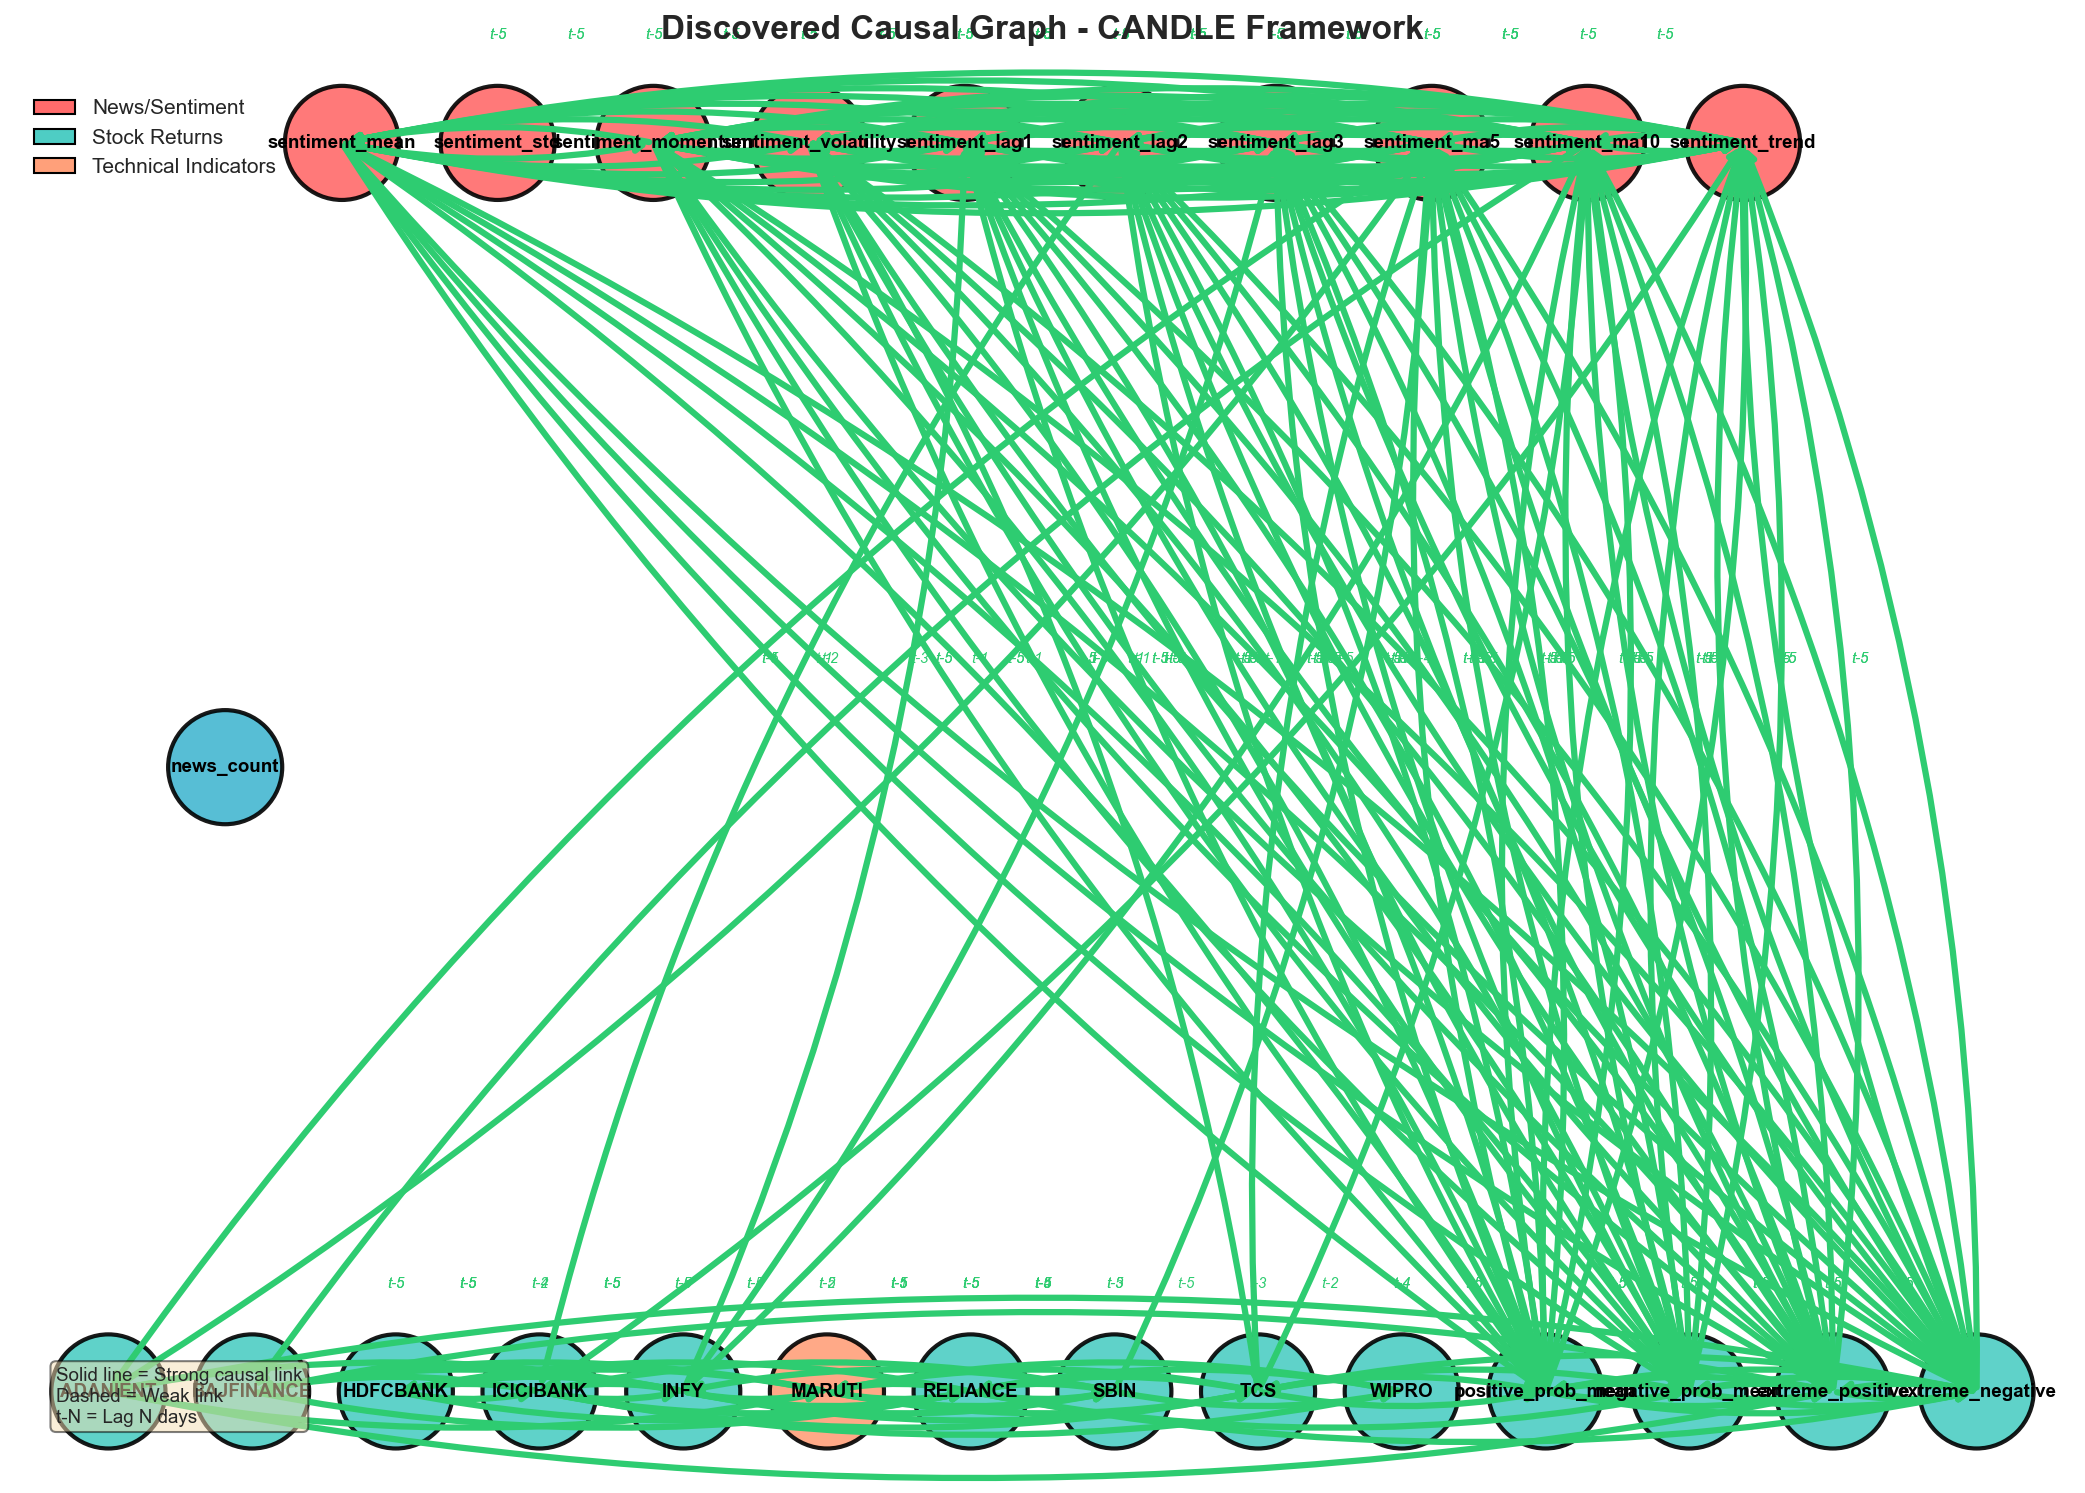


✓ Publication DAG saved to: results/figures/causal_graph_publication.png


In [4]:
# Create DAG visualizer
dag_viz = DAGVisualizer()

# Generate publication DAG
fig = dag_viz.create_publication_dag(
    graph=graph,
    title='Discovered Causal Graph - CANDLE Framework',
    save_path='../results/figures/causal_graph_publication.png',
    figsize=(14, 10)
)

plt.show()

print("\n✓ Publication DAG saved to: results/figures/causal_graph_publication.png")

## 3. Temporal Causal Graph

Show lagged relationships with time dimension.

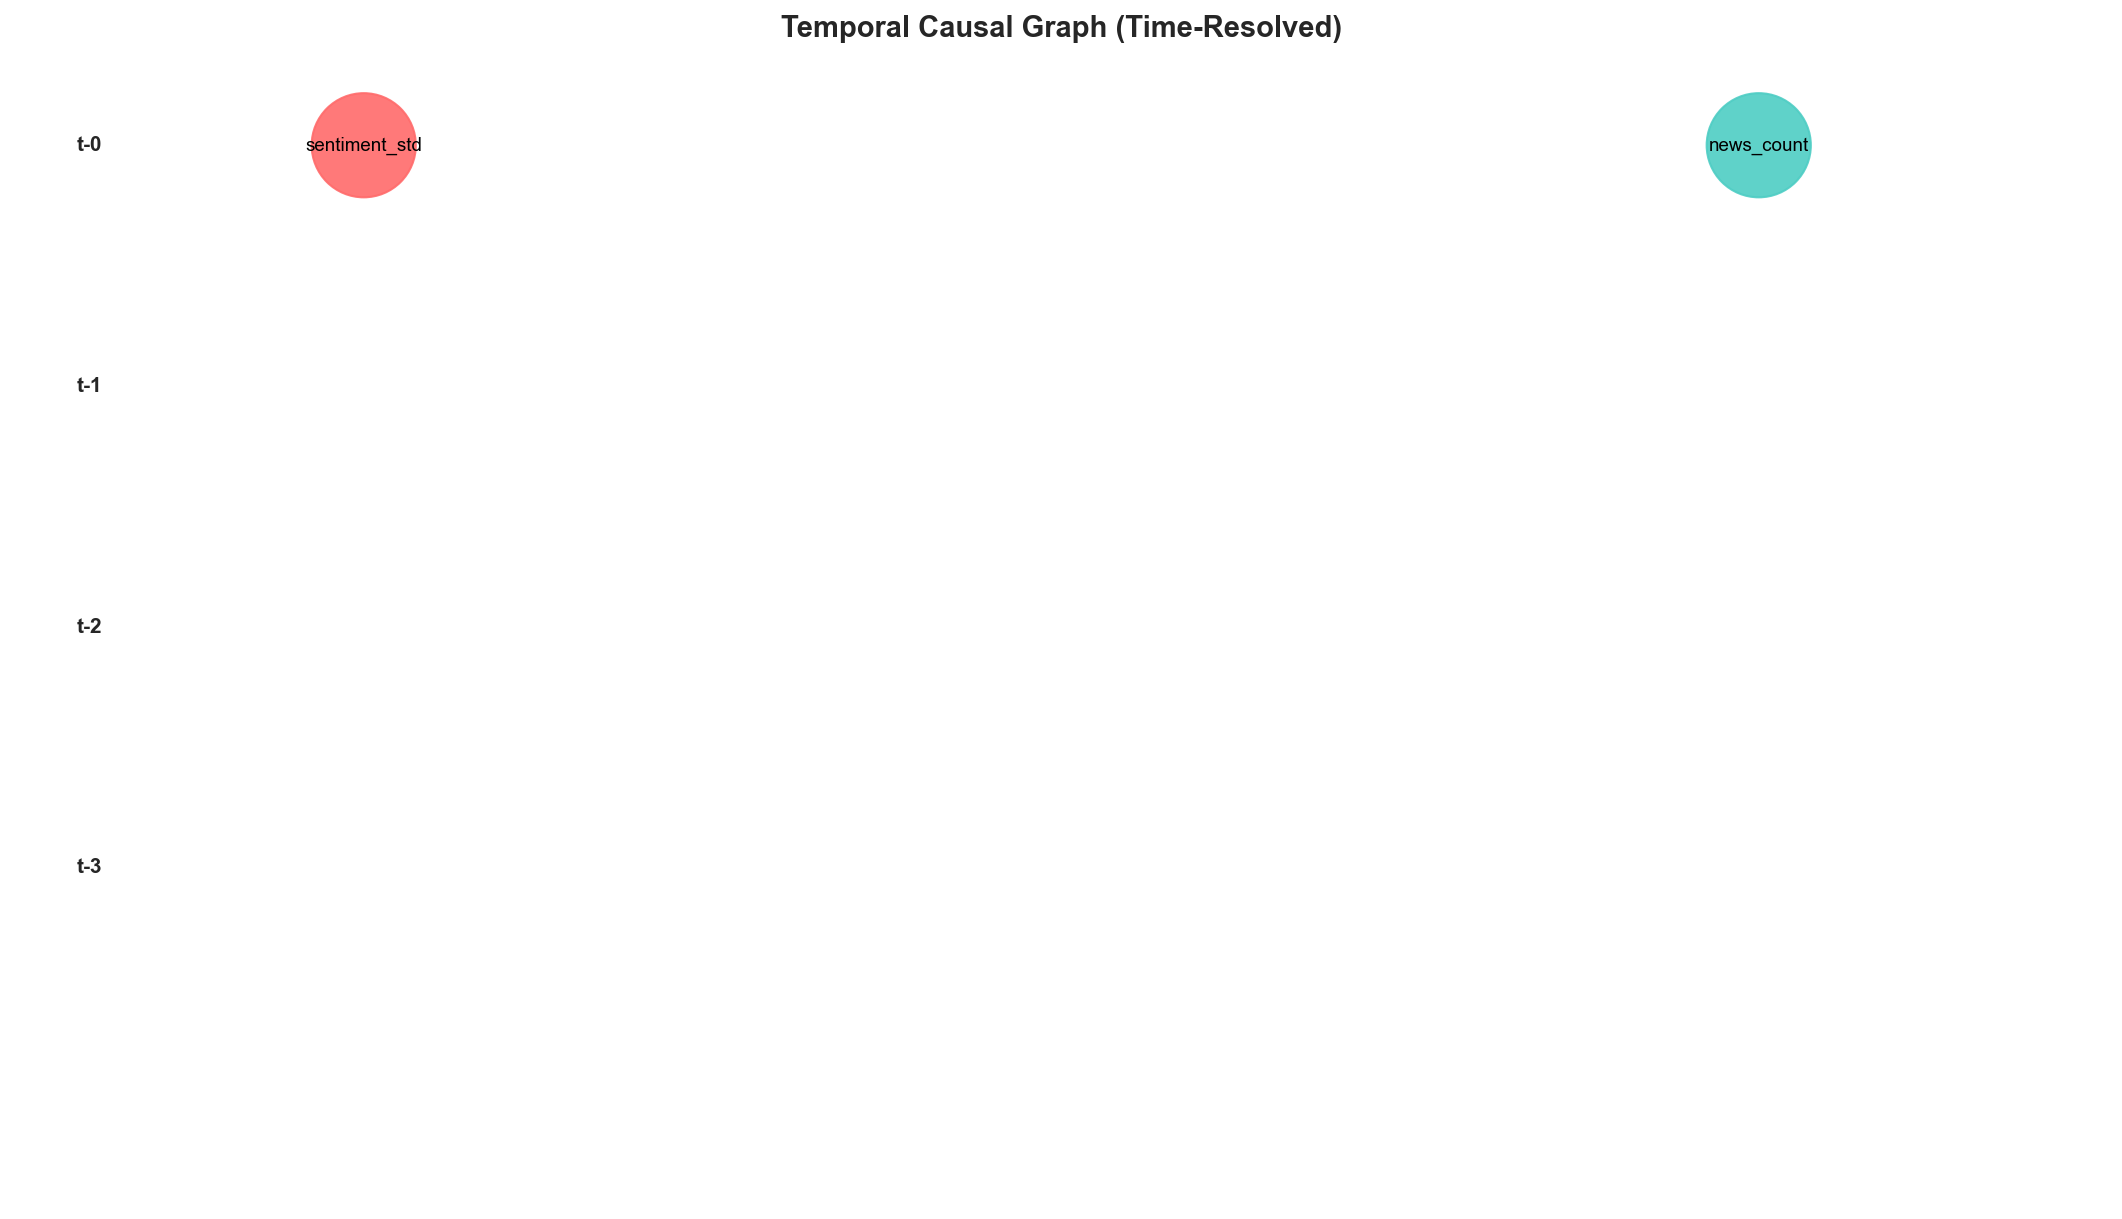


✓ Temporal DAG saved to: results/figures/temporal_causal_graph.png


In [5]:
# Generate temporal DAG
fig = dag_viz.create_temporal_dag(
    graph=graph,
    max_lag=3,
    save_path='../results/figures/temporal_causal_graph.png'
)

plt.show()

print("\n✓ Temporal DAG saved to: results/figures/temporal_causal_graph.png")

## 4. Interactive Architecture Summary

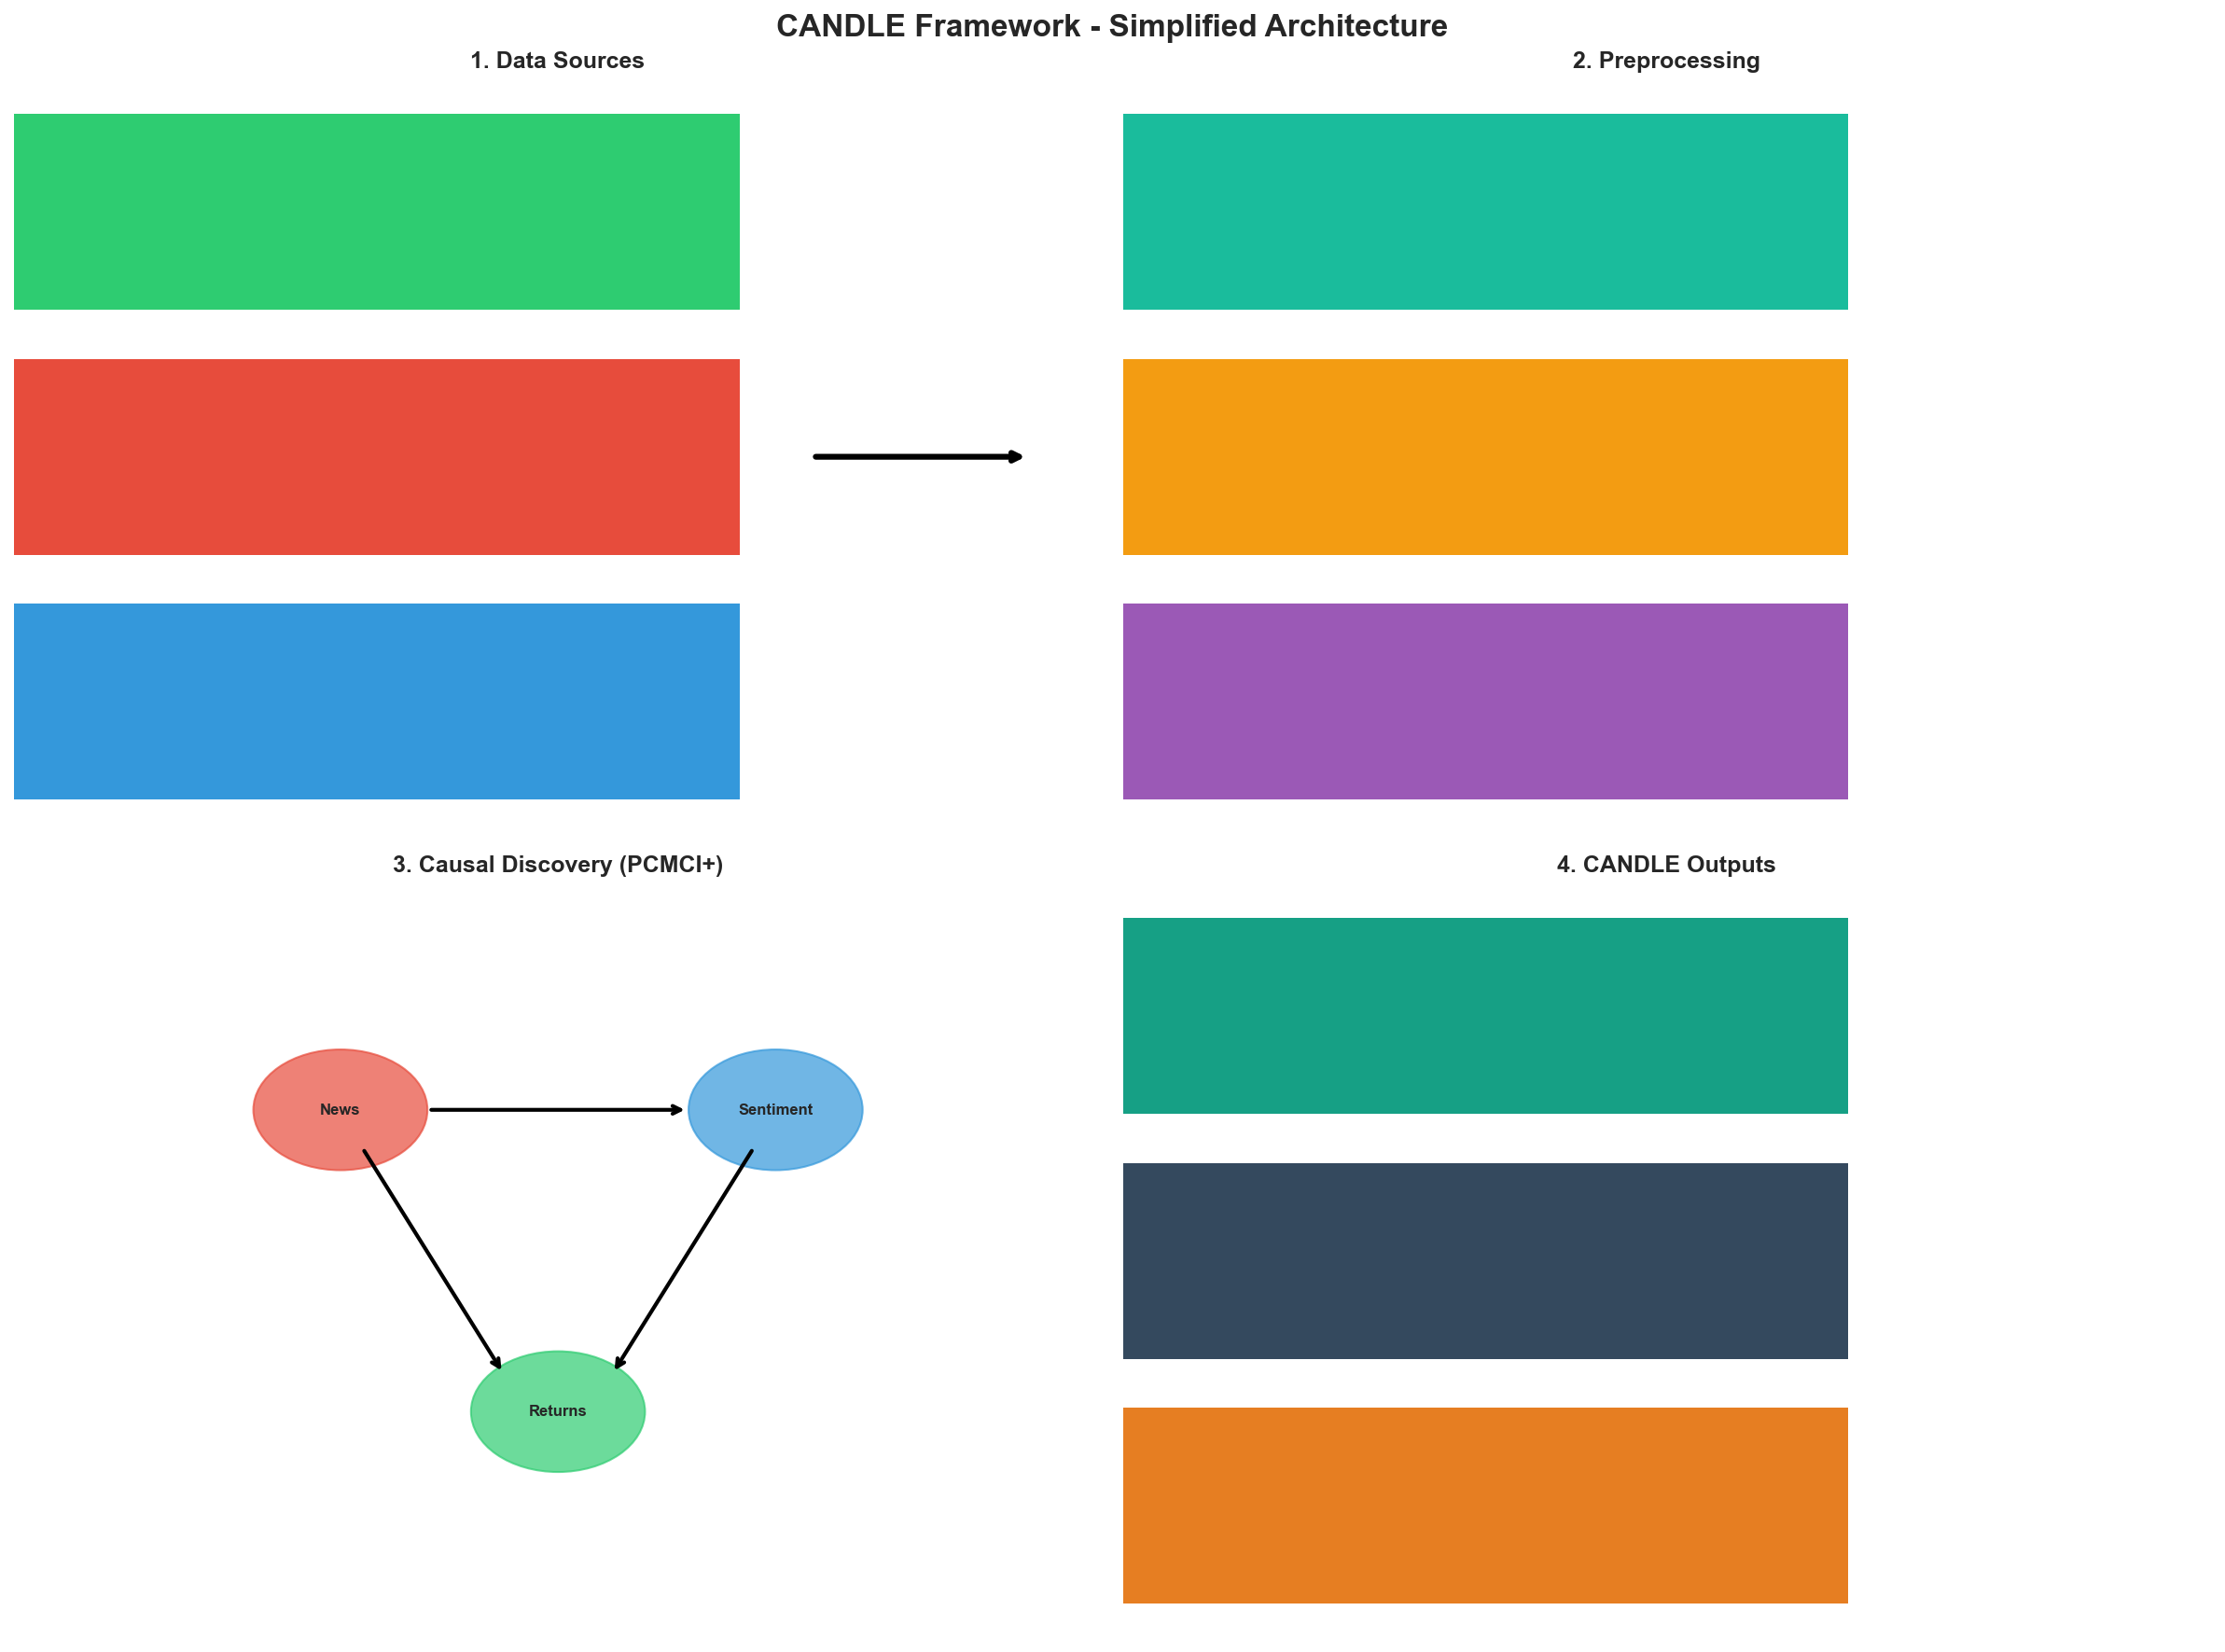


✓ Summary diagram saved to: results/figures/candle_summary.png


In [6]:
# Create a simplified summary diagram
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Data Flow
ax = axes[0, 0]
data_sources = ['Prices', 'News', 'Fundamentals']
y_pos = np.arange(len(data_sources))
ax.barh(y_pos, [1, 1, 1], color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_yticks(y_pos)
ax.set_yticklabels(data_sources)
ax.set_title('1. Data Sources', fontweight='bold')
ax.set_xlim(0, 1.5)
ax.axis('off')

# Add arrow
ax.annotate('', xy=(1.4, 1), xytext=(1.1, 1),
            arrowprops=dict(arrowstyle='->', lw=3, color='black'))

# 2. Processing
ax = axes[0, 1]
steps = ['FinBERT', 'Returns', 'Alignment']
y_pos = np.arange(len(steps))
ax.barh(y_pos, [1, 1, 1], color=['#9b59b6', '#f39c12', '#1abc9c'])
ax.set_yticks(y_pos)
ax.set_yticklabels(steps)
ax.set_title('2. Preprocessing', fontweight='bold')
ax.set_xlim(0, 1.5)
ax.axis('off')

# 3. Causal Discovery
ax = axes[1, 0]
# Draw mini DAG
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('3. Causal Discovery (PCMCI+)', fontweight='bold')

# Nodes
circle1 = plt.Circle((3, 7), 0.8, color='#e74c3c', alpha=0.7)
circle2 = plt.Circle((7, 7), 0.8, color='#3498db', alpha=0.7)
circle3 = plt.Circle((5, 3), 0.8, color='#2ecc71', alpha=0.7)
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

# Edges
ax.annotate('', xy=(6.2, 7), xytext=(3.8, 7), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(4.5, 3.5), xytext=(3.2, 6.5), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(5.5, 3.5), xytext=(6.8, 6.5), arrowprops=dict(arrowstyle='->', lw=2))

ax.text(3, 7, 'News', ha='center', va='center', fontsize=8, fontweight='bold')
ax.text(7, 7, 'Sentiment', ha='center', va='center', fontsize=8, fontweight='bold')
ax.text(5, 3, 'Returns', ha='center', va='center', fontsize=8, fontweight='bold')

# 4. Output
ax = axes[1, 1]
outputs = ['Causal Graph', 'do-Calculus', 'What-If']
y_pos = np.arange(len(outputs))
colors = ['#e67e22', '#34495e', '#16a085']
ax.barh(y_pos, [1, 1, 1], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(outputs)
ax.set_title('4. CANDLE Outputs', fontweight='bold')
ax.set_xlim(0, 1.5)
ax.axis('off')

plt.suptitle('CANDLE Framework - Simplified Architecture', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../results/figures/candle_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Summary diagram saved to: results/figures/candle_summary.png")

## 5. Generate All Visualizations at Once

Architecture diagram saved to ../results/figures/candle_architecture_final.png


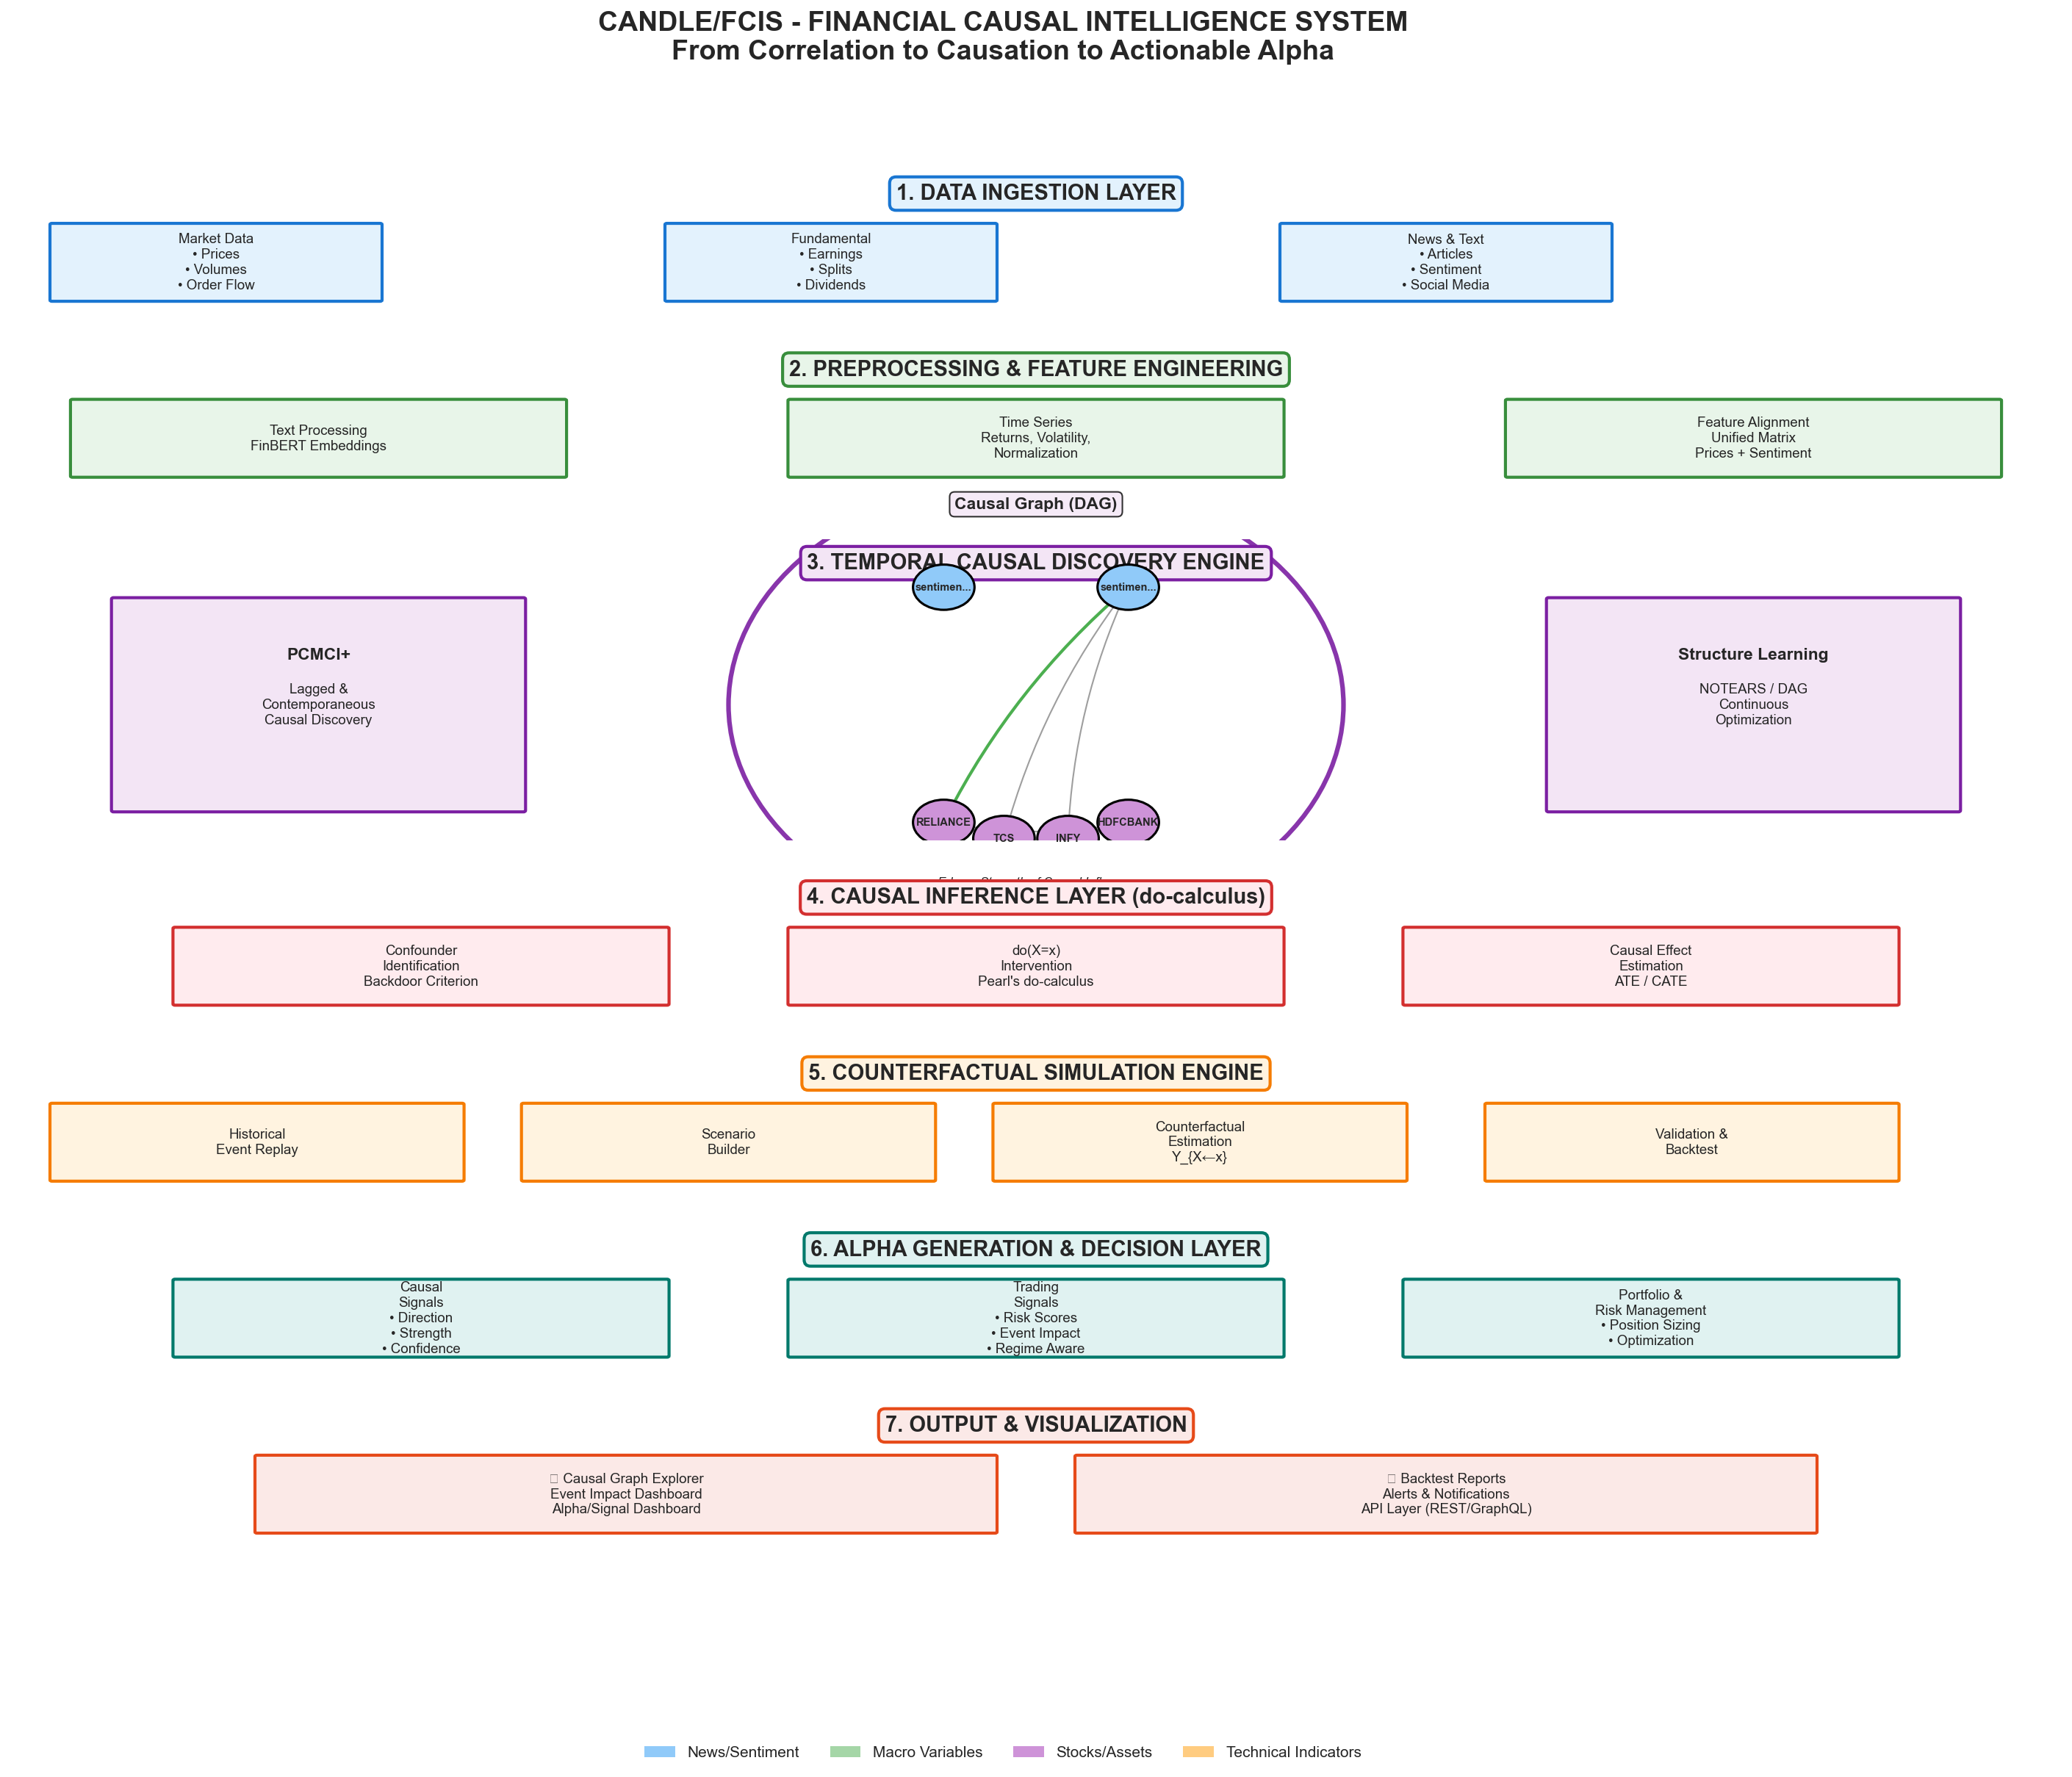


All Architecture Visualizations Generated!

Generated files:
  • candle_full_architecture.png - Complete 7-layer framework
  • causal_graph_publication.png - Publication-quality DAG
  • temporal_causal_graph.png - Time-resolved causal graph
  • candle_summary.png - Simplified 4-box summary
  • candle_architecture_final.png - Auto-generated summary


In [7]:
# Use the convenience function
fig = create_architecture_summary(
    save_path='../results/figures/candle_architecture_final.png'
)

plt.show()

print("\n" + "="*60)
print("All Architecture Visualizations Generated!")
print("="*60)
print("\nGenerated files:")
print("  • candle_full_architecture.png - Complete 7-layer framework")
print("  • causal_graph_publication.png - Publication-quality DAG")
print("  • temporal_causal_graph.png - Time-resolved causal graph")
print("  • candle_summary.png - Simplified 4-box summary")
print("  • candle_architecture_final.png - Auto-generated summary")

## Summary

This notebook generated publication-quality visualizations:

1. **Full Architecture**: 7-layer framework diagram matching the reference image
2. **Publication DAG**: Clean causal graph for papers
3. **Temporal Graph**: Shows lagged relationships with time dimension
4. **Summary Diagram**: Simplified 4-component view

All files saved to `results/figures/` for use in presentations and papers.